# **upvote**

***In this edition, I will analyze goals, missed shots, and everything related to the goals of the tournament 
Please, not an order, vote for me***

# **Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
palette = sns.color_palette("Set1")
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
euro=pd.read_csv('/kaggle/input/uefa-euro-2024-records/matches.csv')

# **Data Exploration**

In [3]:
euro.head()

,match_number,team1,team2,date_of_match,stadium,team1_goals,team2_goals,audience,team1_total_shots,team1_shots_on_target,...,team2_offsides,team2_yellow_cards,team2_red_cards,team2_tackles_won,team2_interceptions,team2_blocks,team2_clearances,team2_keeper_saves,team2_duels_won,team2_successful_dribbles
0,1,Germany,Scotland,15-06-2024,Fuball Arena Mnchen,5,1,"65,052",20,10,...,0,1,1,8(53%),6,5,22,5,41,5(56%)
1,2,Hungary,Switzerland,15-06-2024,Cologne Stadium,1,3,"41,676",6,2,...,2,2,0,9(69%),6,1,17,1,41,5(38%)
2,3,Spain,Croatia,15-06-2024,Olympiastadion Berlin,3,0,"68,844",11,5,...,0,0,0,10(71%),9,3,4,2,47,10(77%)
3,4,Italy,Albania,16-06-2024,BVB Stadion Dortmund,2,1,"60,512",17,5,...,1,2,0,5(63%),13,6,15,3,26,2(29%)
4,5,Poland,Netherlands,16-06-2024,Volksparkstadion,1,2,"48,117",12,7,...,0,1,0,11(79%),3,1,21,6,54,14(70%)


In [4]:
euro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   match_number               51 non-null     int64 
 1   team1                      51 non-null     object
 2   team2                      51 non-null     object
 3   date_of_match              51 non-null     object
 4   stadium                    51 non-null     object
 5   team1_goals                51 non-null     int64 
 6   team2_goals                51 non-null     int64 
 7   audience                   51 non-null     object
 8   team1_total_shots          51 non-null     int64 
 9   team1_shots_on_target      51 non-null     int64 
 10  team2_total_shots          51 non-null     int64 
 11  team2_shots_on_target      51 non-null     int64 
 12  team1_fouls                51 non-null     int64 
 13  team1_corners              51 non-null     int64 
 14  team1_blocke

In [5]:
euro.isnull().sum()

match_number                 0
team1                        0
team2                        0
date_of_match                0
stadium                      0
team1_goals                  0
team2_goals                  0
audience                     0
team1_total_shots            0
team1_shots_on_target        0
team2_total_shots            0
team2_shots_on_target        0
team1_fouls                  0
team1_corners                0
team1_blocked_shots          0
team1_passes                 0
team1_accurate_passes        0
team1_accurate_long_balls    0
team1_accurate_crosses       0
team1_throws                 0
team1_offsides               0
team1_yellowcards            0
team1_red_cards              0
team1_tackles_won            0
team1_interceptions          0
team1_blocks                 0
team1_clearances             0
team1_keeper_saves           0
team1_duels_won              0
team1_successful_dribbles    0
team2_accurate_passes        0
team2_fouls_committed        0
team2_co

In [6]:
euro.duplicated().sum()

0

# **Data Preprocessing & Data visualization**

In [7]:
euro['audience'] = euro['audience'].str.replace(',', '').astype(float)

In [8]:
euro [euro['audience']==euro['audience'].max()]

,match_number,team1,team2,date_of_match,stadium,team1_goals,team2_goals,audience,team1_total_shots,team1_shots_on_target,...,team2_offsides,team2_yellow_cards,team2_red_cards,team2_tackles_won,team2_interceptions,team2_blocks,team2_clearances,team2_keeper_saves,team2_duels_won,team2_successful_dribbles
47,48,Netherlands,Turkiye,07-07-2024,Olympiastadion Berlin,2,1,70091.0,11,4,...,2,1,1,7(41%),12,3,15,3,47,5(42%)


In [9]:
euro [euro['audience']==euro['audience'].min()]

,match_number,team1,team2,date_of_match,stadium,team1_goals,team2_goals,audience,team1_total_shots,team1_shots_on_target,...,team2_offsides,team2_yellow_cards,team2_red_cards,team2_tackles_won,team2_interceptions,team2_blocks,team2_clearances,team2_keeper_saves,team2_duels_won,team2_successful_dribbles
43,44,Austria,Turkiye,03-07-2024,Leipzig Stadium,1,2,38305.0,21,5,...,1,2,0,8(40%),13,7,55,4,56,7(58%)


In [10]:
euro['stadium'].value_counts()

stadium
Fuball Arena Mnchen      6
Olympiastadion Berlin    6
BVB Stadion Dortmund     6
Cologne Stadium          5
Volksparkstadion         5
Stuttgart Arena          5
Frankfurt Arena          5
Dsseldorf Arena          5
Arena AufSchalke         4
Leipzig Stadium          4
Name: count, dtype: int64

In [11]:
total_audience_by_stadium=euro.groupby(['stadium']).agg(stadium_count=('stadium','count'),audience=('audience','sum'))
total_audience_by_stadium=total_audience_by_stadium.sort_values(by='audience',ascending=False).reset_index()

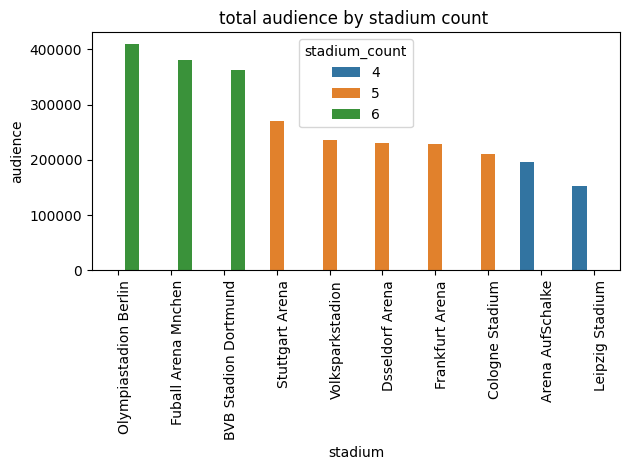

In [12]:
sns.barplot(x='stadium', y='audience', hue='stadium_count', data=total_audience_by_stadium)
plt.title('total audience by stadium count ')
plt.xticks(rotation=90, ha='left') 
plt.tight_layout()
plt.show()

In [13]:
stadium_attendance=euro.groupby('stadium')['audience'].sum().sort_values(ascending=False)
print(stadium_attendance)
print('The total attendance at matches inside the stadium in the Euro 2024 tournament is:',stadium_attendance.sum())

stadium
Olympiastadion Berlin    410525.0
Fuball Arena Mnchen      381013.0
BVB Stadion Dortmund     362952.0
Stuttgart Arena          270000.0
Volksparkstadion         236897.0
Dsseldorf Arena          230638.0
Frankfurt Arena          229652.0
Cologne Stadium          210691.0
Arena AufSchalke         195341.0
Leipzig Stadium          153579.0
Name: audience, dtype: float64
The total attendance at matches inside the stadium in the Euro 2024 tournament is: 2681288.0


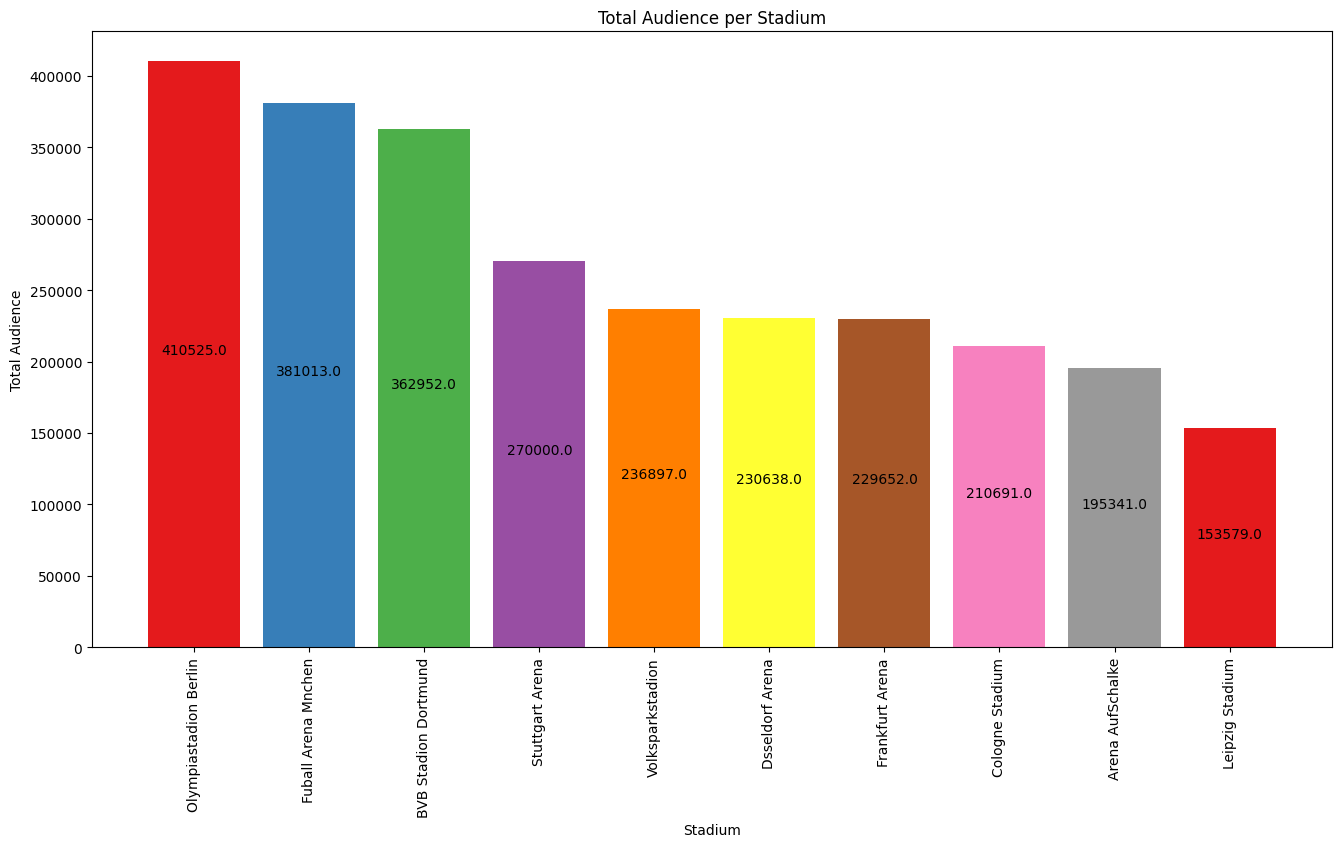

In [14]:
plt.figure(figsize=(16, 8))
plt.bar(stadium_attendance.index,stadium_attendance,color=palette)
for i in range(len(stadium_attendance)):
    plt.text(i , stadium_attendance[i]//2,stadium_attendance[i], ha ='center')
plt.title('Total Audience per Stadium')
plt.xlabel('Stadium')
plt.ylabel('Total Audience')
plt.xticks(rotation=90)
plt.show()

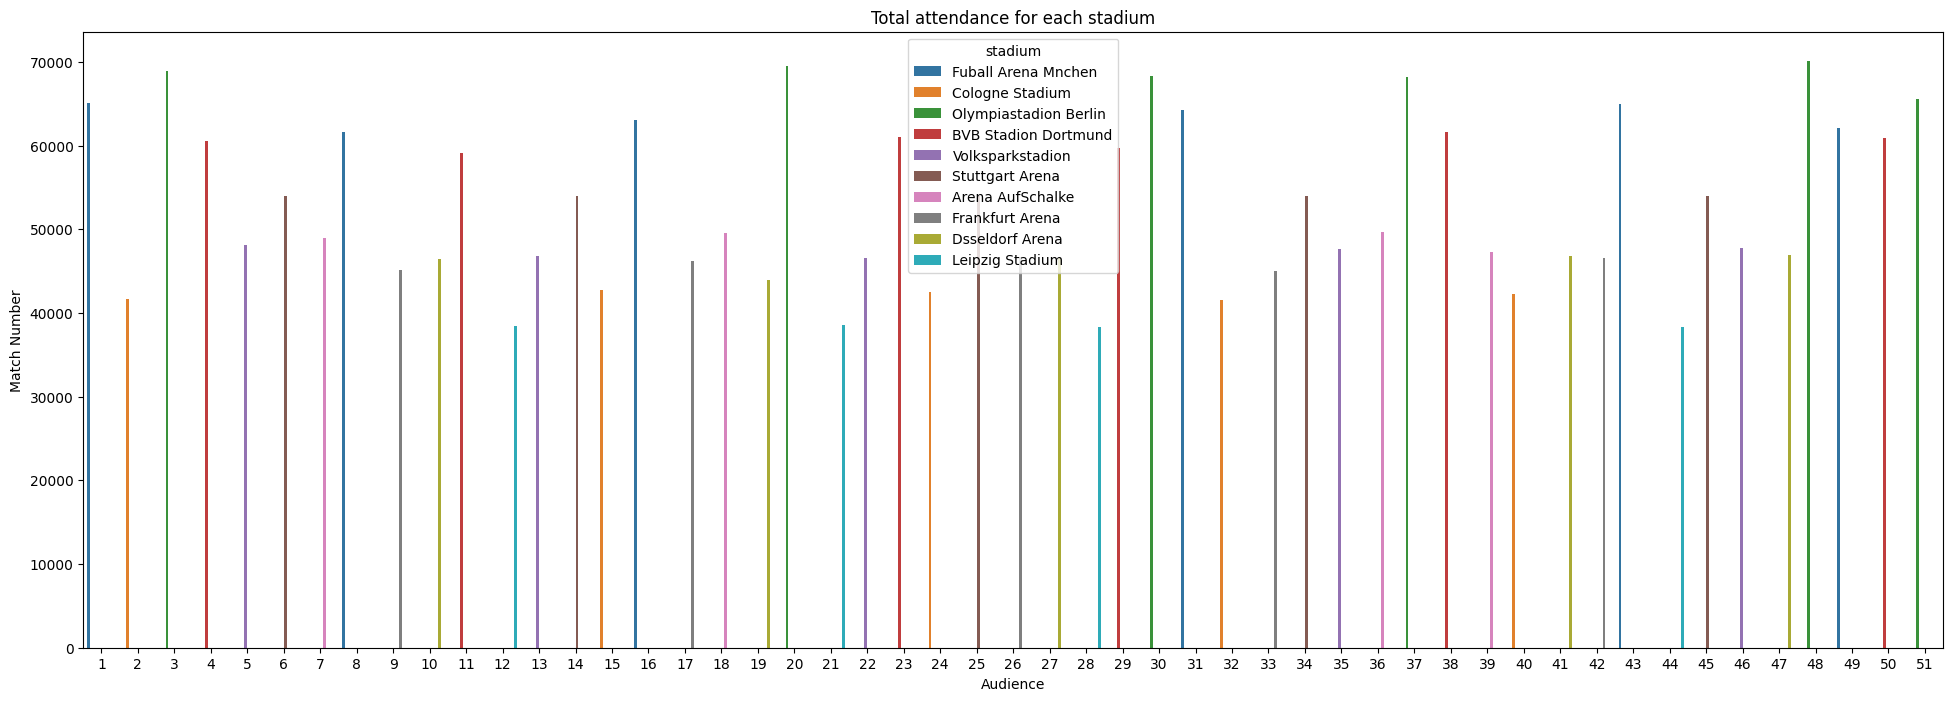

In [15]:
plt.figure(figsize=(24, 8))
sns.barplot(x=euro['match_number'],y=euro['audience'],hue=euro['stadium'])
plt.ylabel('Match Number')
plt.xlabel("Audience")
plt.title('Total attendance for each stadium')
plt.show()


In [16]:
euro['team']=euro['team1'] #this step for make index = team not team1

In [17]:
team_goal=euro.groupby('team')['team1_goals'].sum()+euro.groupby('team2')['team2_goals'].sum()
team_goal.sort_values(ascending=False)

team
Spain          15
Germany        11
Netherlands    10
Turkiye         8
Switzerland     8
England         8
Austria         7
Georgia         5
Portugal        5
Slovakia        4
France          4
Romania         4
Poland          3
Albania         3
Italy           3
Czechia         3
Croatia         3
Hungary         2
Scotland        2
Denmark         2
Slovenia        2
Belgium         2
Ukraine         2
Serbia          1
dtype: int64

In [18]:
team_shot_on_target=euro.groupby('team')['team1_shots_on_target'].sum()+euro.groupby('team2')['team2_shots_on_target'].sum()
team_shot_on_target.sort_values(ascending=False)

team
Spain          44
Germany        34
Portugal       26
England        25
France         24
Turkiye        23
Netherlands    22
Austria        22
Switzerland    21
Belgium        20
Czechia        20
Croatia        19
Slovakia       16
Denmark        16
Romania        16
Poland         13
Albania        12
Hungary        11
Ukraine        11
Italy          10
Slovenia        9
Georgia         9
Serbia          6
Scotland        3
dtype: int64

In [19]:
team_shot=euro.groupby('team')['team1_total_shots'].sum() + euro.groupby('team2')['team2_total_shots'].sum()
team_shot

team
Albania         33
Austria         51
Belgium         53
Croatia         44
Czechia         44
Denmark         53
England         76
France          96
Georgia         30
Germany         95
Hungary         31
Italy           44
Netherlands     81
Poland          37
Portugal        88
Romania         37
Scotland        17
Serbia          26
Slovakia        50
Slovenia        36
Spain          122
Switzerland     57
Turkiye         72
Ukraine         39
dtype: int64

In [20]:
team_matches_played = euro.groupby('team1')['team1'].count() + euro.groupby('team2')['team2'].count()
team_matches_played.sort_values(ascending=False)

team1
England        7
Spain          7
Netherlands    6
France         6
Turkiye        5
Switzerland    5
Portugal       5
Germany        5
Austria        4
Romania        4
Slovenia       4
Georgia        4
Italy          4
Denmark        4
Belgium        4
Slovakia       4
Serbia         3
Albania        3
Scotland       3
Poland         3
Hungary        3
Czechia        3
Croatia        3
Ukraine        3
dtype: int64

In [21]:
all_shots = pd.DataFrame({'total shots': team_shot,'total shots on target': team_shot_on_target, 'team goal':team_goal,'team matches played':team_matches_played})
all_shots['total shots out target']=all_shots['total shots']- all_shots['total shots on target']
all_shots['goals from shot on target pct'] = (all_shots['team goal'] / all_shots['total shots on target']) * 100  
all_shots['shot on target pct'] = (all_shots['total shots on target'] / all_shots['total shots']) * 100  
all_shots['total shots per match'] = all_shots['total shots'] / all_shots['team matches played']
all_shots['shots on target per match'] = all_shots['total shots on target'] / all_shots['team matches played']
all_shots['goal per match'] = all_shots['team goal'] / all_shots['team matches played']
all_shots.sort_values(by='team goal',ascending=False)

,total shots,total shots on target,team goal,team matches played,total shots out target,goals from shot on target pct,shot on target pct,total shots per match,shots on target per match,goal per match
Spain,122,44,15,7,78,34.090909,36.065574,17.428571,6.285714,2.142857
Germany,95,34,11,5,61,32.352941,35.789474,19.000000,6.800000,2.200000
Netherlands,81,22,10,6,59,45.454545,27.160494,13.500000,3.666667,1.666667
Turkiye,72,23,8,5,49,34.782609,31.944444,14.400000,4.600000,1.600000
Switzerland,57,21,8,5,36,38.095238,36.842105,11.400000,4.200000,1.600000
England,76,25,8,7,51,32.000000,32.894737,10.857143,3.571429,1.142857
Austria,51,22,7,4,29,31.818182,43.137255,12.750000,5.500000,1.750000
Georgia,30,9,5,4,21,55.555556,30.000000,7.500000,2.250000,1.250000
Portugal,88,26,5,5,62,19.230769,29.545455,17.600000,5.200000,1.000000
Slovakia,50,16,4,4,34,25.000000,32.000000,12.500000,4.000000,1.000000


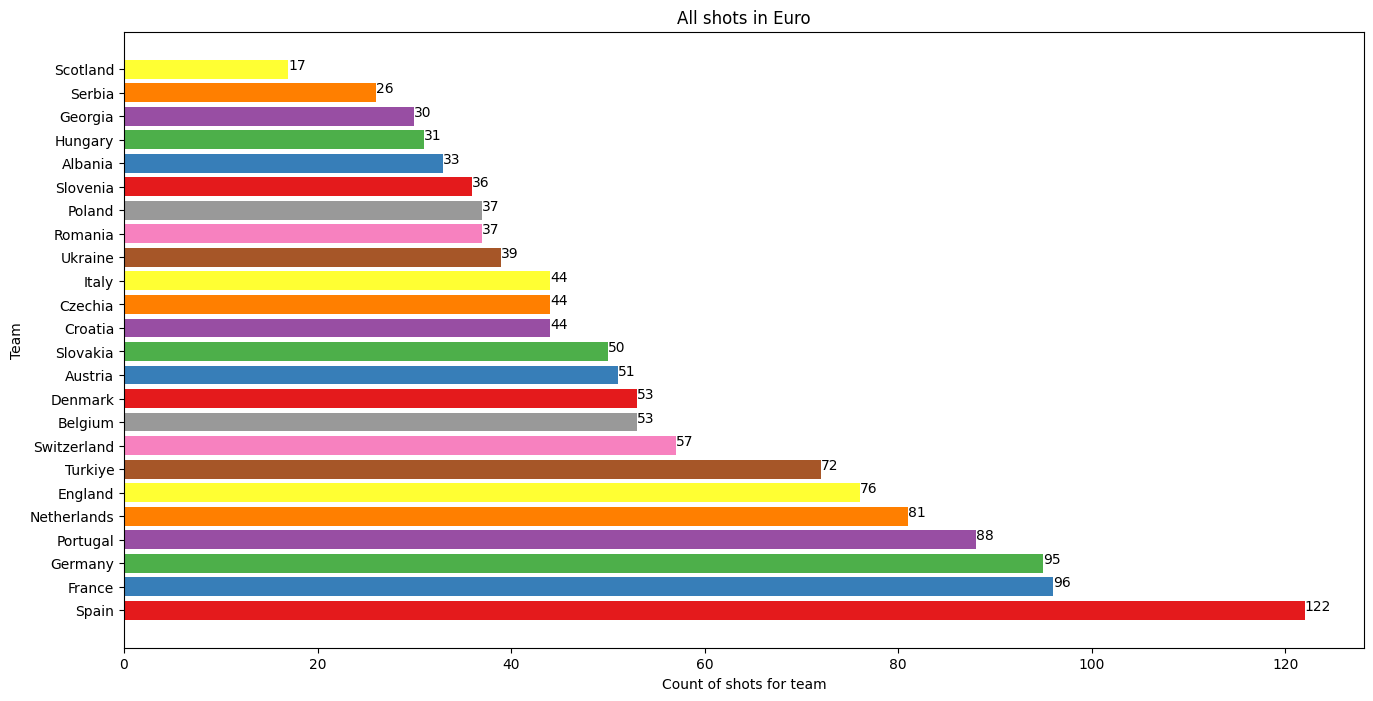

In [22]:
total_shots=all_shots['total shots'].sort_values(ascending=False)
plt.figure(figsize=(16, 8))
plt.barh(total_shots.index,total_shots,color= palette)
for index , value in enumerate(total_shots):
    plt.text(value , index, str(value))
plt.ylabel('Team')
plt.xlabel("Count of shots for team")
plt.title('All shots in Euro')
plt.show()

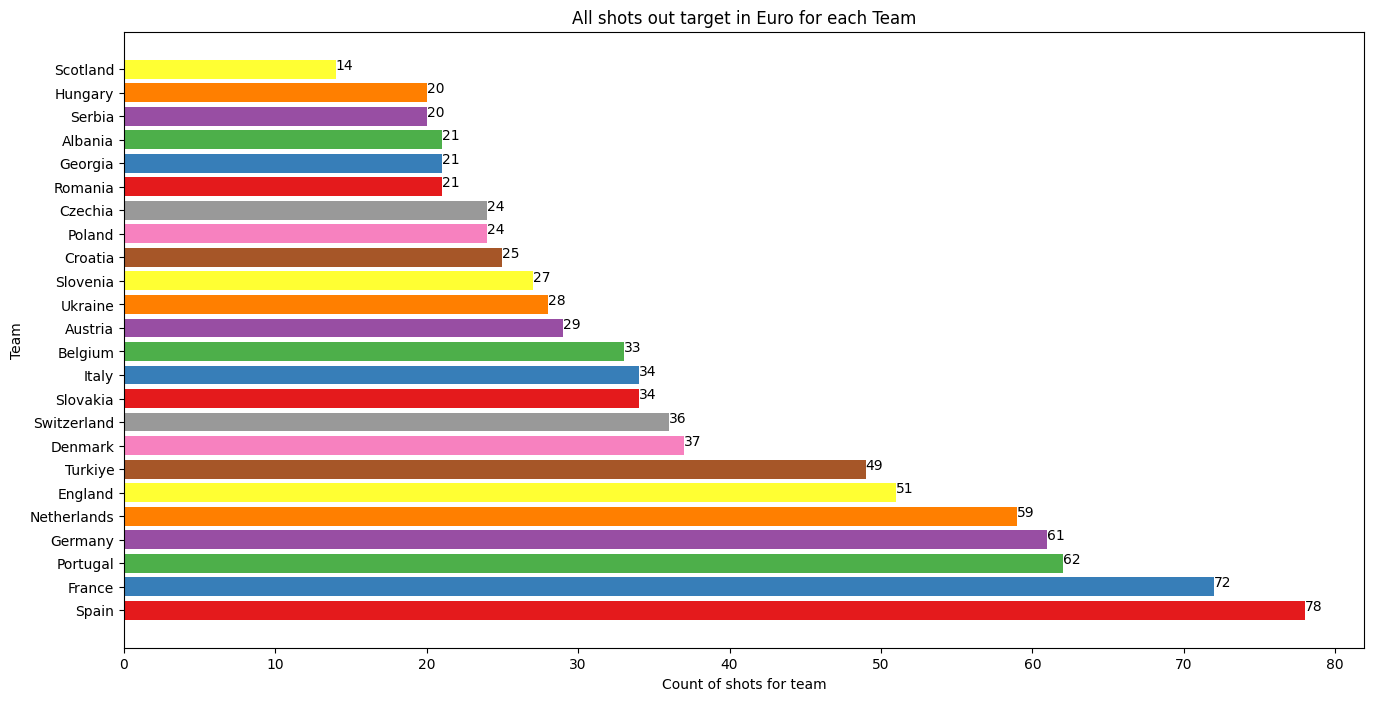

In [23]:
total_shots_out_target=all_shots['total shots out target'].sort_values(ascending=False)
plt.figure(figsize=(16, 8))
plt.barh(total_shots_out_target.index,total_shots_out_target,color= palette)
for index , value in enumerate(total_shots_out_target):
    plt.text(value , index, str(value))
plt.ylabel('Team')
plt.xlabel("Count of shots for team")
plt.title('All shots out target in Euro for each Team')
plt.show()

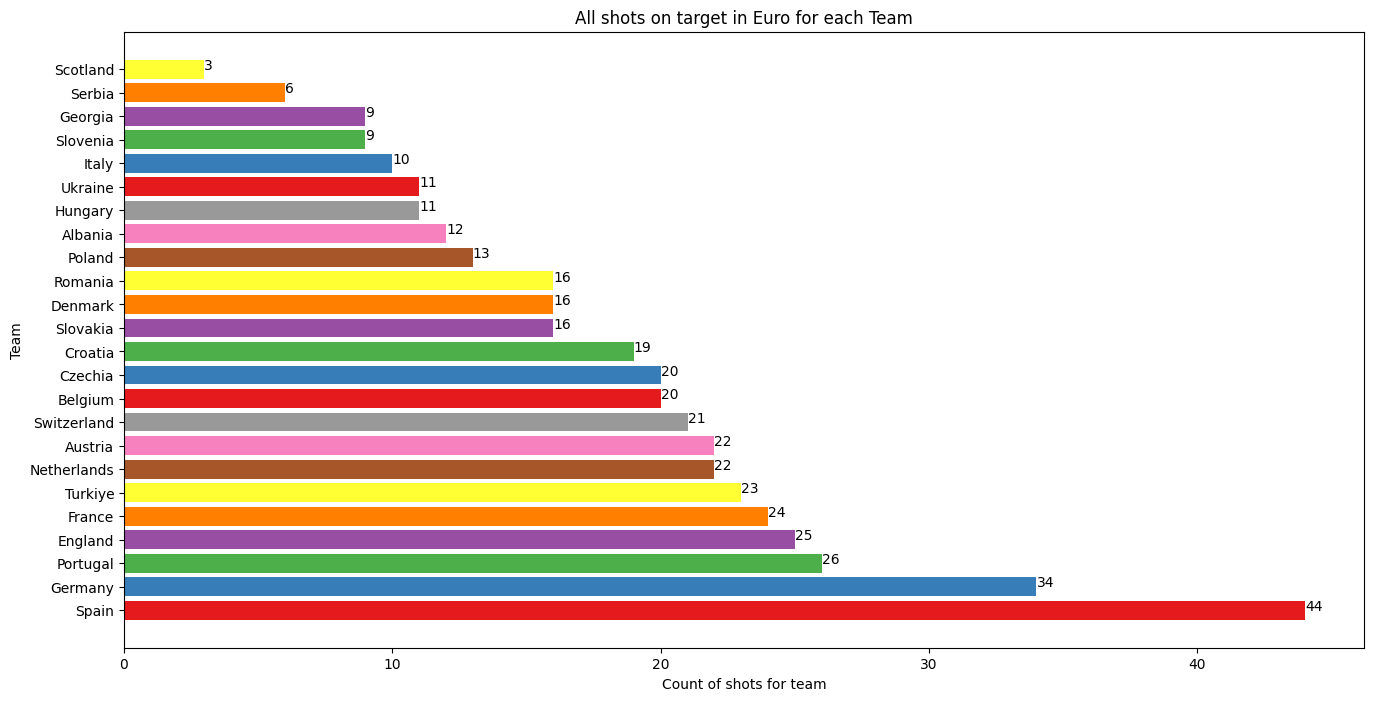

In [24]:
total_shots_on_target=all_shots['total shots on target'].sort_values(ascending=False)
plt.figure(figsize=(16, 8))
plt.barh(total_shots_on_target.index,total_shots_on_target,color= palette)
for index , value in enumerate(total_shots_on_target):
    plt.text(value , index, str(value))
plt.ylabel('Team')
plt.xlabel("Count of shots for team")
plt.title('All shots on target in Euro for each Team')
plt.show()

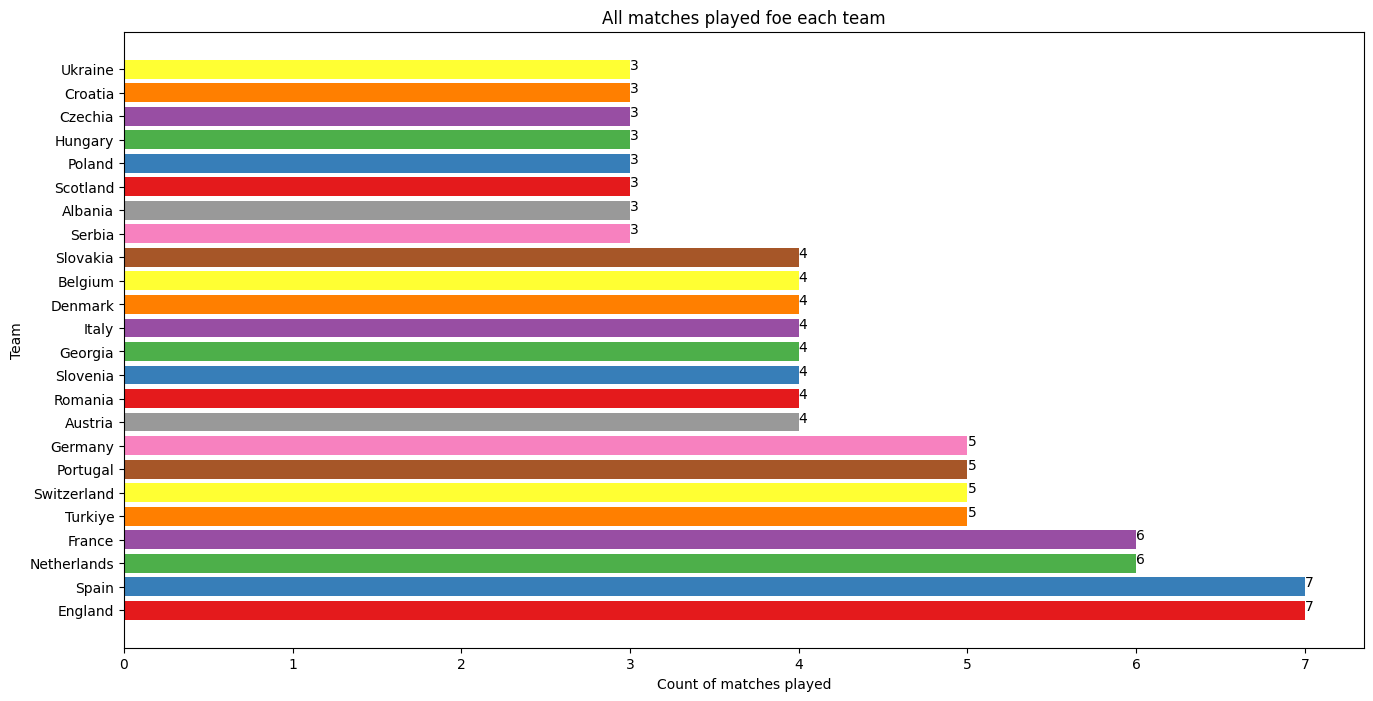

In [25]:
team_matches_played=all_shots['team matches played'].sort_values(ascending=False)
plt.figure(figsize=(16, 8))
plt.barh(team_matches_played.index,team_matches_played,color= palette)
for index , value in enumerate(team_matches_played):
    plt.text(value , index, str(value))
plt.ylabel('Team')
plt.xlabel("Count of matches played")
plt.title('All matches played foe each team')
plt.show()

Number of goals scored during the tournament 117
Spain          15
Germany        11
Netherlands    10
Turkiye         8
Switzerland     8
England         8
Austria         7
Georgia         5
Portugal        5
Slovakia        4
France          4
Romania         4
Poland          3
Albania         3
Italy           3
Czechia         3
Croatia         3
Hungary         2
Scotland        2
Denmark         2
Slovenia        2
Belgium         2
Ukraine         2
Serbia          1
Name: team goal, dtype: int64


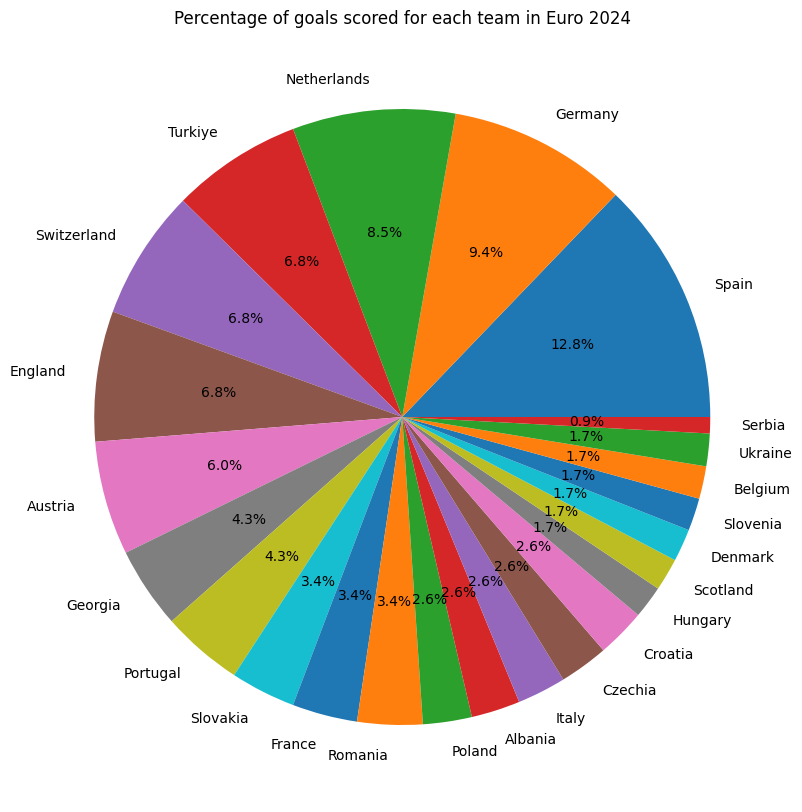

In [26]:
print('Number of goals scored during the tournament', all_shots['team goal'].sum())
goals=all_shots['team goal'].sort_values(ascending=False)
print(goals)
plt.figure(figsize=(20, 10))
plt.pie(goals,autopct='%1.1f%%',labels=goals.index)
plt.title("Percentage of goals scored for each team in Euro 2024")
plt.show()

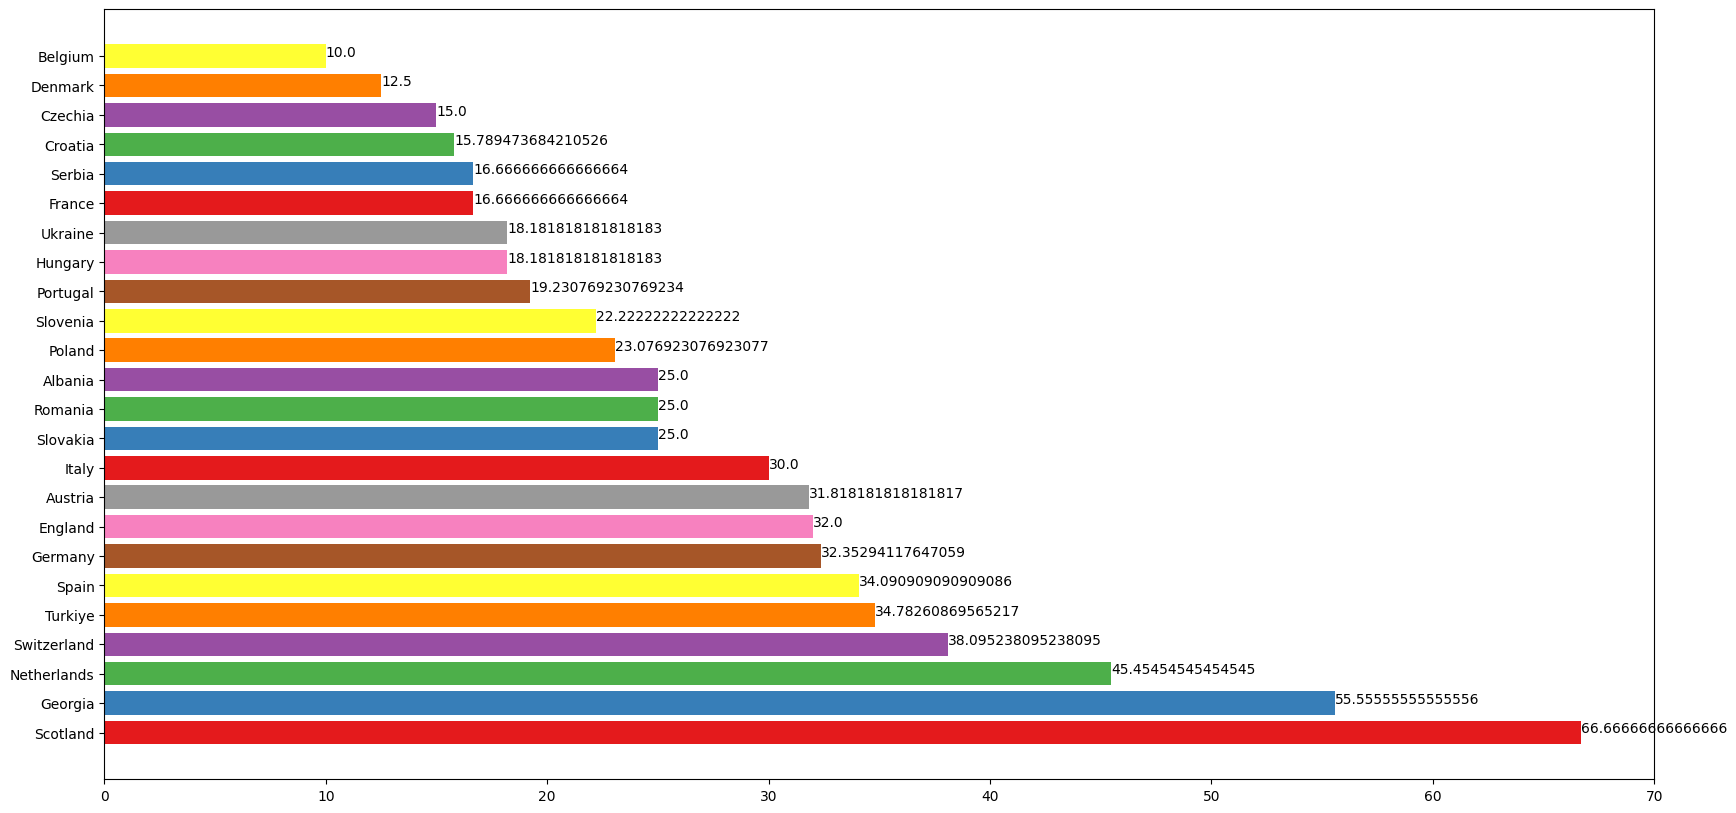

In [27]:
goals_from_shot_pct= all_shots['goals from shot on target pct'].sort_values(ascending=False)
plt.figure(figsize=(20, 10))
plt.barh(goals_from_shot_pct.index,goals_from_shot_pct,color = palette)
for index , value in enumerate(goals_from_shot_pct):
    plt.text(value , index, str(value))
plt.show()

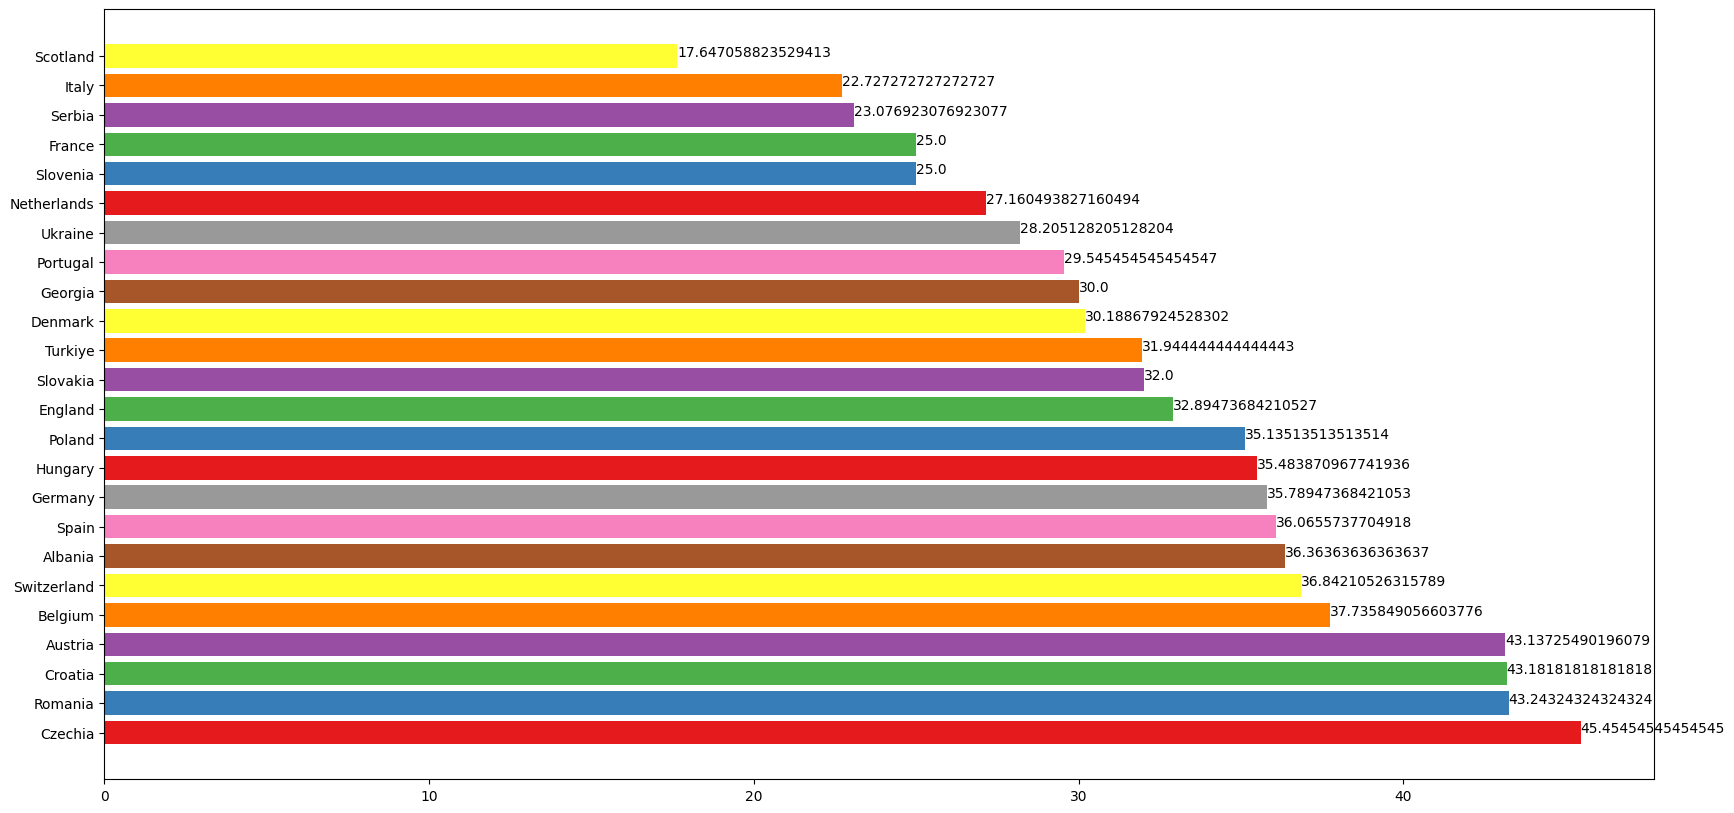

In [28]:
shot_pct= all_shots['shot on target pct'].sort_values(ascending=False)
plt.figure(figsize=(20, 10))
plt.barh(shot_pct.index,shot_pct,color = palette)
for index , value in enumerate(shot_pct):
    plt.text(value , index, str(value))
plt.show()

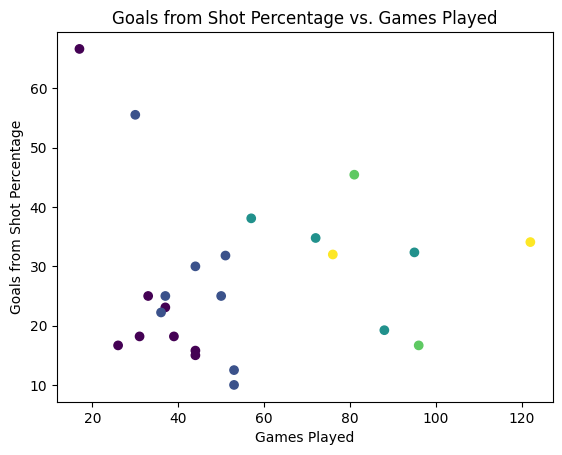

In [29]:
plt.scatter(all_shots['total shots'], all_shots['goals from shot on target pct'], c=all_shots['team matches played'])
plt.xlabel('Games Played')
plt.ylabel('Goals from Shot Percentage')
plt.title('Goals from Shot Percentage vs. Games Played')
plt.show()

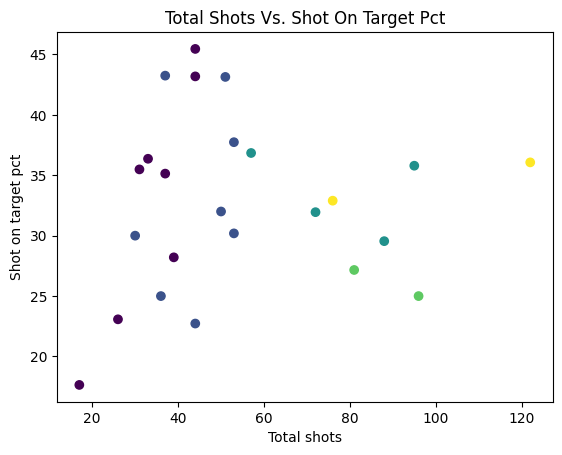

In [30]:
plt.scatter(all_shots['total shots'], all_shots['shot on target pct'], c =all_shots['team matches played'])
plt.xlabel('Total shots')
plt.ylabel('Shot on target pct')
plt.title('Total Shots Vs. Shot On Target Pct')
plt.show()

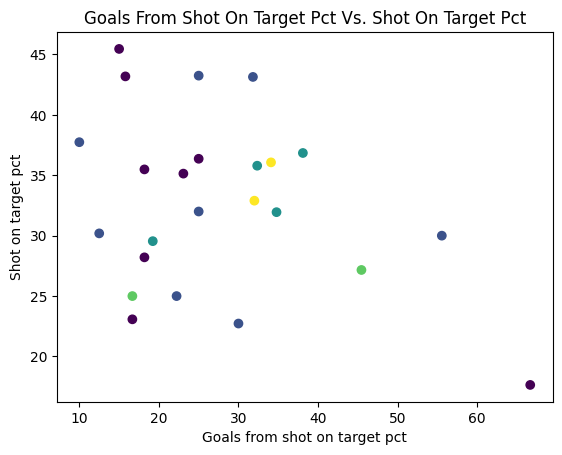

In [31]:
plt.scatter(all_shots['goals from shot on target pct'], all_shots['shot on target pct'], c=all_shots['team matches played'])
plt.xlabel('Goals from shot on target pct')
plt.ylabel('Shot on target pct')
plt.title('Goals From Shot On Target Pct Vs. Shot On Target Pct')
plt.show()

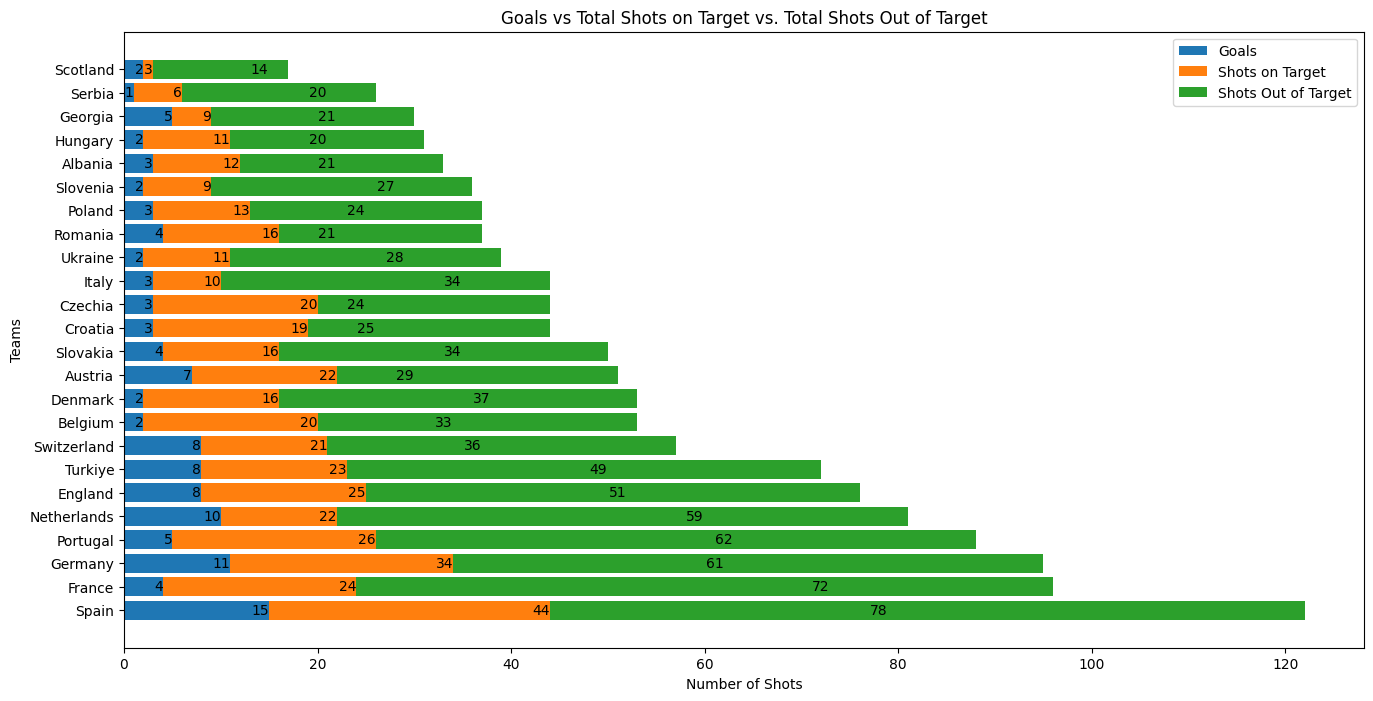

In [32]:
all_shots = all_shots.sort_values(by='total shots', ascending=False)
plt.figure(figsize=(16, 8))

bars1 = plt.barh(all_shots['total shots'].index, all_shots['team goal'], label='Goals')
for index , value in enumerate( all_shots['team goal']):
    plt.text(value , index, str(value),ha='right' ,va='center')

bars2 = plt.barh(all_shots['total shots'].index, all_shots['total shots on target'],left = all_shots['team goal'] ,label='Shots on Target')


for index , value in enumerate(all_shots['total shots on target']):
    plt.text(value , index, str(value),ha='right' ,va='center')

bars3 = plt.barh(all_shots['total shots'].index, all_shots['total shots out target'], left=all_shots['total shots on target'], label='Shots Out of Target')

for index , value in enumerate(all_shots['total shots out target']):
    plt.text(value , index, str(value),ha='center' ,va='center')
plt.xlabel('Number of Shots')
plt.ylabel('Teams')
plt.title('Goals vs Total Shots on Target vs. Total Shots Out of Target')
plt.legend()

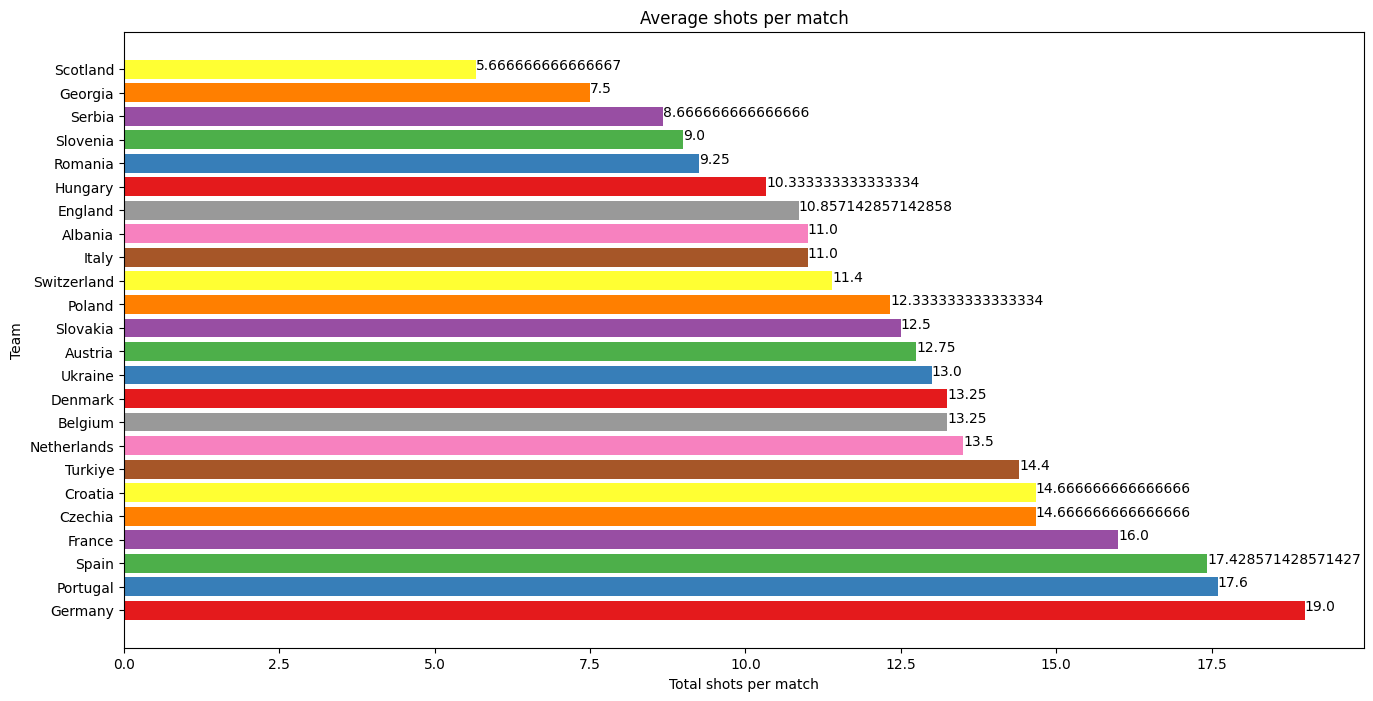

In [33]:
total_shots_per_match=all_shots['total shots per match'].sort_values(ascending=False)
plt.figure(figsize=(16, 8))
plt.barh(total_shots_per_match.index,total_shots_per_match,color= palette)
for index , value in enumerate(total_shots_per_match):
    plt.text(value , index, str(value))
plt.ylabel('Team')
plt.xlabel("Total shots per match")
plt.title('Average shots per match')
plt.show()

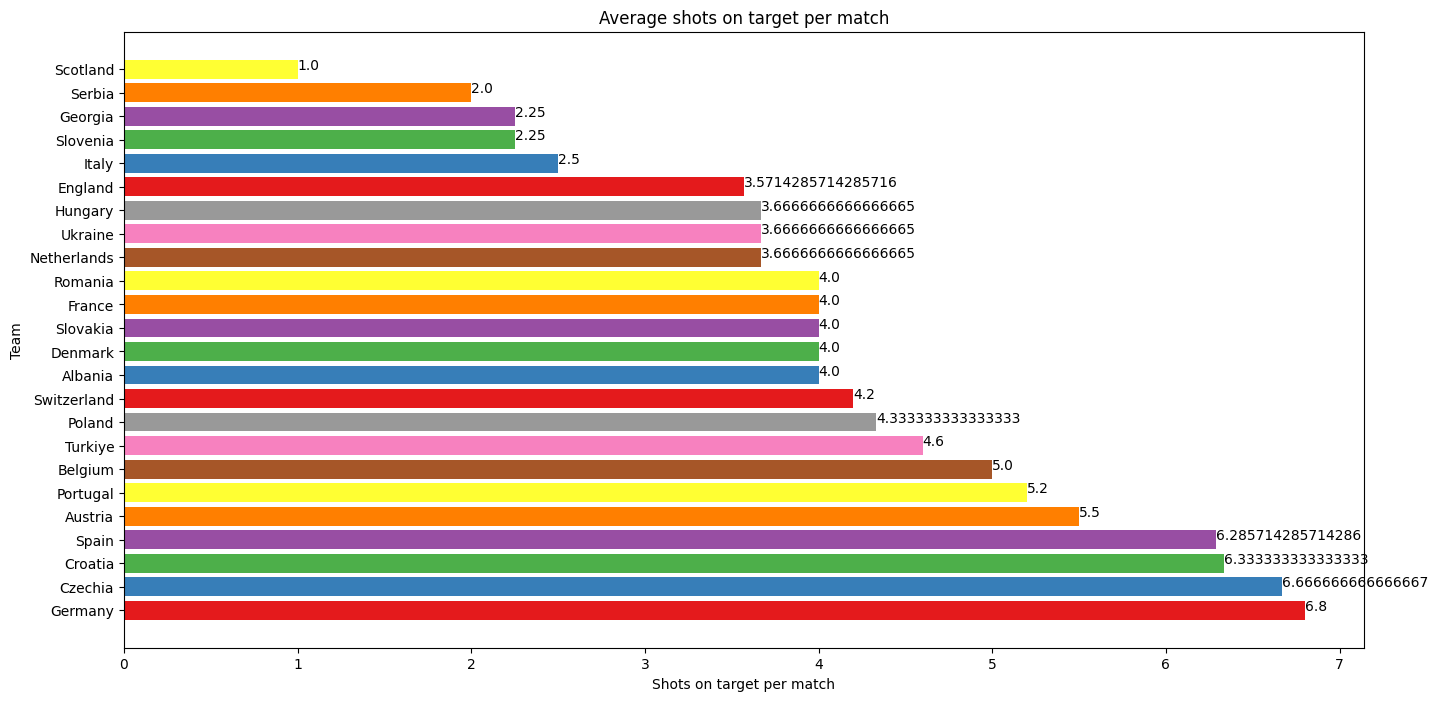

In [34]:
shots_on_target_per_match=all_shots['shots on target per match'].sort_values(ascending=False)
plt.figure(figsize=(16, 8))
plt.barh(shots_on_target_per_match.index,shots_on_target_per_match,color= palette)
for index , value in enumerate(shots_on_target_per_match):
    plt.text(value , index, str(value))
plt.ylabel('Team')
plt.xlabel("Shots on target per match")
plt.title('Average shots on target per match')
plt.show()

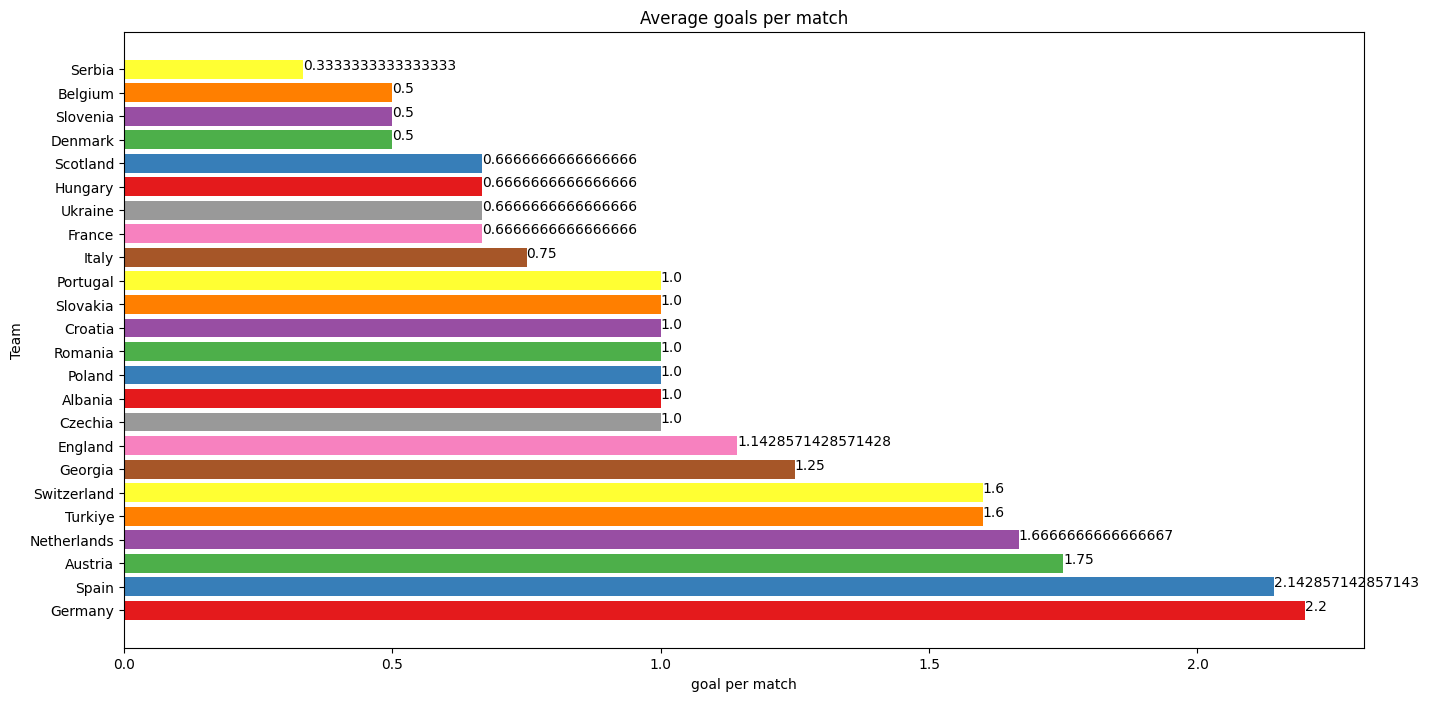

In [35]:
goal_per_match=all_shots['goal per match'].sort_values(ascending=False)
plt.figure(figsize=(16, 8))
plt.barh(goal_per_match.index,goal_per_match,color= palette)
for index , value in enumerate(goal_per_match):
    plt.text(value , index, str(value))
plt.ylabel('Team')
plt.xlabel("goal per match")
plt.title('Average goals per match')
plt.show()

# **Some conclusions**

**1- Germany hosted the Euro 2024 tournament.
As 51 matches were played in 10 stadiums, it is the first edition of the Euro Championship to be hosted by one country after the number of teams increased.**

**2- Fußball Arena München and Olympiastadion Berlin and BVB Stadion Dortmund Cologne Stadium
They are the stadiums that host the most matches in the Euro 2024 tournament, with 6 matches per stadium**

**3- The total attendance for matches inside the stadium in the Euro 2024 tournament is 2,681,288**

**4- Olympiastadion Berlin
It is the stadium that witnessed the largest attendance in the tournament.
Leipzig Stadium
It is the stadium that witnessed the lowest audience attendance in the tournament**

**5- The match between Türkiye and the Netherlands witnessed the highest crowd attendance in the Euro 2024 tournament.
The match between Türkiye and Austria  witnessed the lowest crowd attendance in Euro 2024**

**6- The Euro 2024 tournament was full of goals, with 117 goals in 51 matches**

**7- The Spanish team is the defending champion and scored 15 goals with 122 shots on target, proving that it is the team with the strongest attacking line in the tournament.**

**I hope I covered all aspects Dont forget to upvote**